<a href="https://colab.research.google.com/github/rominesgmd/Phase4/blob/main/Phase_3_Model_Selection%2C_Training%2C_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries and Dataset



In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
!pip install -q kaggle



#Rerun IMPORT

In [19]:
# Import Dataset
import kagglehub

# Download latest version
path  = kagglehub.dataset_download("sumedh1507/teen-phone-addiction")

print("Path to dataset files:", path)

# Load Dataset
df = pd.read_csv("/kaggle/input/teen-phone-addiction/teen_phone_addiction_dataset.csv")

# Data Preprocessing
df = df.drop(columns=['ID', 'Name'])

Using Colab cache for faster access to the 'teen-phone-addiction' dataset.
Path to dataset files: /kaggle/input/teen-phone-addiction


# Data Preprocessing

In [20]:
# Encode categorical variables into numerical values so the models can process them.
le = LabelEncoder()
categorical_cols = [
    'Location',
    'School_Grade',
    'Phone_Usage_Purpose',
    'Gender'
]
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Define Features (X) and Target (y)
# The target variable is Addiction_Level, which is continuous.
X = df.drop(columns=['Addiction_Level'])
y = df['Addiction_Level']

# Model Training

In [21]:
# Split the data into training (80%) and testing (20%) sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline Model (Linear Regression)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression training complete.")

# Complex Model (Random Forest Regressor)
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Regressor training complete.")

# Hyperparameter Tuning for Random Forest Regressor for GridSearchCV
# The paramters were already set explicitly from the results of `grid_search.best_params_`
# Define the grid of hyperparameters to explore
gscv_param_grid = {
    'n_estimators': [200],      # Number of trees
    'max_depth': [20],          # Maximum depth of the trees
  'min_samples_split': [2]      # Minimum samples required to split a node
}
# Setup GridSearchCV
grid_search_cv = GridSearchCV(estimator=rf_model, param_grid=gscv_param_grid,
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the grid search to the training data
grid_search_cv.fit(X_train, y_train)

# Select the best model
best_rf_model = grid_search_cv.best_estimator_

print("Tuned Random Forest training via GridSearchCV complete.")

Linear Regression training complete.
Random Forest Regressor training complete.
Tuned Random Forest training via GridSearchCV complete.


# Model Evaluation

In [ ]:
# Generate Predictions
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
best_rf_preds = best_rf_model.predict(X_test)

# Evaluate Using Metrics (Regression)
# We use MSE and R² as Addiction_Level is a continuous target variable.
models = {
    "Linear Regression (Baseline)": lr_preds,
    "Random Forest (Complex)": rf_preds,
    "Tuned Random Forest (GridSearchCV)": best_rf_preds
}

print("--- Model Evaluation Metrics ---")
for name, preds in models.items():
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name}:")
    print(f"  Mean Squared Error (MSE): {mse:.4f}")
    print(f"  R-squared (R²): {r2:.4f}\n")

# Cross-Validation (K-Fold)
# Action: Use 5-fold cross-validation to validate how well the best model generaliz.
# We use the full feature set (X) and target (y) for cross-validation.
print("--- Cross-Validation Results ---")
scoring = ['r2', 'neg_mean_squared_error']
results = cross_validate(best_rf_model, X, y, cv=5, scoring=scoring)
mse_scores = -results['test_neg_mean_squared_error']
r2_scores = results['test_r2']
print(f"R-squared (R²) Mean: {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})")
print(f"Mean Squared Error (MSE) Mean: {mse_scores.mean():.4f}")

--- Model Evaluation Metrics ---
Linear Regression (Baseline):
  Mean Squared Error (MSE): 0.6658
  R-squared (R²): 0.7357

Random Forest (Complex):
  Mean Squared Error (MSE): 0.3442
  R-squared (R²): 0.8634

Tuned Random Forest (GridSearchCV):
  Mean Squared Error (MSE): 0.3392
  R-squared (R²): 0.8654

--- Cross-Validation Results ---


# Model Improvement

In [ ]:
# Feature Engineering
# Action: Create new features to leverage the full potential of behavioral and psychological data.
# Create a 'Usage_Intensity' score by combining daily hours and check frequency.
df['Usage_Intensity'] = df['Daily_Usage_Hours'] * df['Phone_Checks_Per_Day']

# Create a 'Mental_Health_Index' by combining Anxiety and Depression while subtracting Self-Esteem.
df['Mental_Health_Index'] = (df['Anxiety_Level'] + df['Depression_Level']) - df['Self_Esteem']

# Re-apply Label Encoding to categorical columns in df before defining X_improved
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Define improved Features (X) and continuous Target (y)
X_improved = df.drop(columns=['Addiction_Level'])
y_improved = df['Addiction_Level']

# Split the improved dataset into training (80%) and testing (20%) sets.
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_improved, y_improved, test_size=0.2, random_state=42
)

# Experiment with Complex Models (Ensemble Methods)
# Action: Use XGBoost to combine multiple weak learners for superior performance.
xgb_model = XGBRegressor(random_state=42)

# Hyperparameter Tuning (RandomizedSearchCV)
# Action: Find the optimal balance of tree depth and learning rate to prevent overfitting.
# The paramters were already set explicitly from the results of `random_search.best_estimator_`
xgb_param_dist = {
    'n_estimators': [200],
    'learning_rate': [0.05],
    'max_depth': [20],
    'subsample': [0.7]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

# Fit the tuner to the improved training data
random_search.fit(X_train_imp, y_train_imp)

# Select the best performing XGBoost model
best_xgb_model = random_search.best_estimator_

# Evaluation of the Improved Model
# Predict on the improved test set
xgb_preds = best_xgb_model.predict(X_test_imp)

print("\n--- Improved Model Performance (XGBoost) ---")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_imp, xgb_preds):.4f}")
print(f"R-squared (R²): {r2_score(y_test_imp, xgb_preds):.4f}")

# Model Interpretation and Reporting


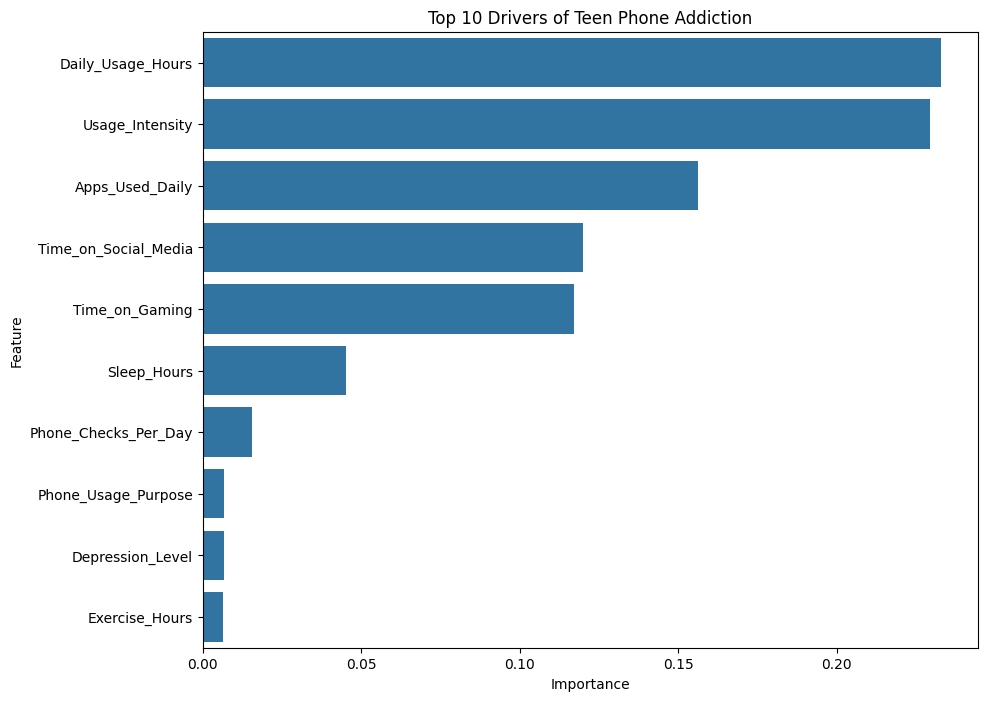

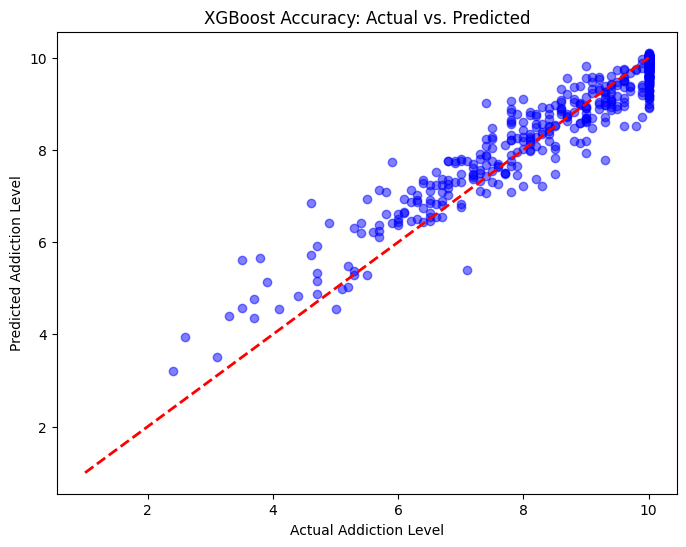

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance Visualization
# This helps us understand which behaviors or traits are most predictive of addiction.
importances = best_xgb_model.feature_importances_
feature_names = X_improved.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Drivers of Teen Phone Addiction')
plt.show()

# Regression Plot: Actual vs. Predicted
# This visualizes the model's accuracy on the continuous target Addiction_Level.
plt.figure(figsize=(8, 6))
plt.scatter(y_test_imp, xgb_preds, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Ideal prediction line
plt.xlabel('Actual Addiction Level')
plt.ylabel('Predicted Addiction Level')
plt.title('XGBoost Accuracy: Actual vs. Predicted')
plt.show()